In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
job_data = {
    'job_id': [1, 2, 3, 4, 5],
    'job_title': ['Data Scientist', 'Software Engineer', 'Product Manager', 'Marketing Director', 'HR Manager'],
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'job_location': ['Mountain View, CA', 'Redmond, WA', 'Cupertino, CA', 'Beaverton, OR', 'Seattle, WA']
}

company_data = {
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'industry': ['Technology', 'Technology', 'Technology', 'Apparel', 'Food & Beverage'],
    'company_size': ['100,000+', '100,000+', '100,000+', '75,000+', '346,000+']
}

df_jobs = pd.DataFrame(job_data)
df_companies = pd.DataFrame(company_data)

In [3]:
# Merging two data frames
df_jobs.merge(df_companies, on="company_name")

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [13]:
df_us = df[df["job_country"] == "United States"].copy()
df_us["job_posted_month"] = df_us["job_posted_date"].dt.strftime("%B")
df_us_pivot = df_us.pivot_table(index="job_posted_month", columns="job_title_short", aggfunc="size")
df_us_pivot = df_us_pivot.reset_index()
df_us_pivot["job_posted_month_no"] = pd.to_datetime(df_us_pivot["job_posted_month"], format="%B").dt.month
df_us_pivot = df_us_pivot.sort_values("job_posted_month_no")
df_us_pivot = df_us_pivot.set_index(df_us_pivot["job_posted_month"])
df_us_pivot = df_us_pivot.drop(columns='job_posted_month_no')

df_us_pivot


job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,,
January,January,527,36,8494,2655,6915,60,1544,773,1552,114
February,February,447,24,6124,3060,4956,56,1258,878,1127,90
March,March,438,19,6218,3183,4779,59,1114,829,1150,115
April,April,565,40,6049,2801,4867,51,1025,781,991,112
May,May,279,20,4993,2976,4377,49,839,746,914,90
June,June,446,32,5683,2893,4645,48,1009,812,1033,93
July,July,581,39,5201,2570,4876,65,883,747,1095,153
August,August,903,39,6634,3269,6318,68,1186,903,1515,194
September,September,897,50,4639,3224,4568,113,805,775,1014,228


In [5]:
# Generating random data
import pandas as pd
import numpy as np

np.random.seed(42)

# Generate dates for all 12 months
months = pd.date_range(start="2025-01-01", end="2025-12-01", freq="MS")

job_titles = [
    "Front-End Developer",
    "Back-End Developer",
    "Full-Stack Developer",
    "UI/UX Designer"
]

data = []

for date in months:
    for job in job_titles:
        salary = np.random.randint(40000, 150000)
        data.append([date, date.strftime("%B"), job, salary])

# Create long format DataFrame
df_long = pd.DataFrame(data, columns=[
    "job_month_date", "job_posted_month", "job_title", "salary"
])

#print(df_long.head())

df_pivot = df_long.pivot(
    index="job_posted_month",        # Rows → Months
    columns="job_title",      # Columns → Job titles
    values="salary"           # Values → Salaries
)

# Ensure correct month order
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

df_us_software_pivot = df_pivot.reindex(month_order)
df_us_software_pivot.columns.name = None
df_us_software_pivot

,Back-End Developer,Front-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,40860,55795,143694,116820
February,46265,94886,122386,77194
March,84131,127498,100263,56023
April,107221,81090,104820,40769
May,102955,99735,104925,107969
June,143355,45311,144724,123104
July,125305,93707,68693,111932
August,146970,133016,65658,124478
September,42747,58431,99150,105725


In [6]:
df_us_merged = df_us_pivot.merge(
    df_us_software_pivot,
    left_index=True,
    right_index=True
)

df_us_merged

,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Back-End Developer,Front-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,,
January,January,527,36,8494,2655,6915,60,1544,773,1552,114,40860,55795,143694,116820
February,February,447,24,6124,3060,4956,56,1258,878,1127,90,46265,94886,122386,77194
March,March,438,19,6218,3183,4779,59,1114,829,1150,115,84131,127498,100263,56023
April,April,565,40,6049,2801,4867,51,1025,781,991,112,107221,81090,104820,40769
May,May,279,20,4993,2976,4377,49,839,746,914,90,102955,99735,104925,107969
June,June,446,32,5683,2893,4645,48,1009,812,1033,93,143355,45311,144724,123104
July,July,581,39,5201,2570,4876,65,883,747,1095,153,125305,93707,68693,111932
August,August,903,39,6634,3269,6318,68,1186,903,1515,194,146970,133016,65658,124478
September,September,897,50,4639,3224,4568,113,805,775,1014,228,42747,58431,99150,105725


In [7]:
# find top 5 job titles (columns) in df_US_merged
numeric_df = df_us_merged.select_dtypes(include=[np.number])

top_5 = (
        numeric_df
         .sum()
         .sort_values(ascending=False)
         .head(5)
         .index
         .tolist()
)

top_5

['Full-Stack Developer',
 'UI/UX Designer',
 'Back-End Developer',
 'Front-End Developer',
 'Data Analyst']

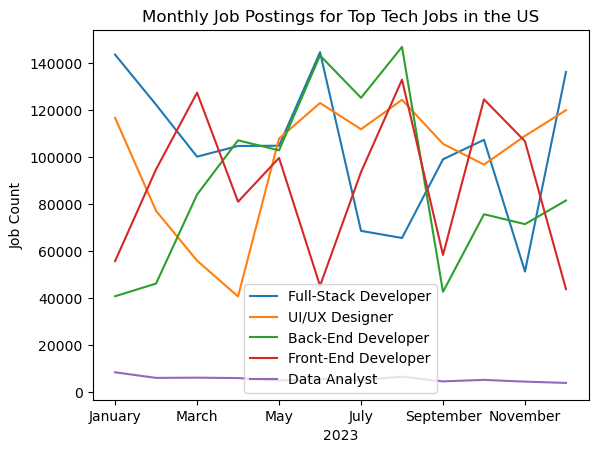

In [8]:
df_us_merged[top_5].plot(kind='line')
plt.title('Monthly Job Postings for Top Tech Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()

In [9]:
# HTML5 Chart rendering
import plotly.express as px

# Convert index → column
df_plot = df_us_merged.drop(columns=["job_posted_month"]).reset_index()

fig = px.line(
    df_plot,
    x="job_posted_month",
    y=top_5,
    title="Monthly Job Postings for Top Tech Jobs in the US"
)

fig.update_layout(
    xaxis_title="2023",
    yaxis_title="Job Count",
    legend_title="Job Titles"
)

fig.write_html("job_trends.html")
fig.show()

In [10]:
df_da = df[df["job_title_short"] == "Data Analyst"]
df_da["month"] = df_da["job_posted_date"].dt.month
df_da_pivot = df_da.pivot_table(index="month", aggfunc="count")["job_title_short"]

df_da_pivot

month
1     23585
2     16558
3     16243
4     15514
5     13423
6     16008
7     16095
8     18628
9     14969
10    16239
11    15230
12    13583
Name: job_title_short, dtype: int64

In [11]:
df_sda = df[df["job_title_short"] == "Senior Data Analyst"]
df_sda["month"] = df["job_posted_date"].dt.month
df_sda_pivot = df_sda.pivot_table(index="month", aggfunc="count")["job_title_short"]

df_sda_pivot

month
1     3696
2     2713
3     2454
4     2351
5     1925
6     2319
7     2380
8     2951
9     2194
10    2317
11    2117
12    1799
Name: job_title_short, dtype: int64

In [12]:
df_da_sda_merged = pd.merge(df_da_pivot,df_sda_pivot, how="outer", left_index=True, right_index=True)
df_da_sda_merged.columns = ["da_count", "sda_count"]
df_da_sda_merged

,da_count,sda_count
month,,
1,23585,3696
2,16558,2713
3,16243,2454
4,15514,2351
5,13423,1925
6,16008,2319
7,16095,2380
8,18628,2951
9,14969,2194
